# Ridge Regression

Ridge Regression is a regularized version of Linear Regression that prevents overfitting by adding a penalty term to the loss function.

## Import libraries and dataset


In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
import pandas as pd
#Importing the dataset
df = pd.read_csv('/content/india_housing_prices.csv', on_bad_lines='skip')
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [ ]:
pd.set_option('display.max_columns', None)
df.sample(5)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
109412,109413,Haryana,Faridabad,Locality_183,Apartment,4,4722,339.02,0.07,2017,Unfurnished,10,19,8,10,10,Low,Yes,No,Gym,West,Owner,Ready_to_Move
174886,174887,West Bengal,Durgapur,Locality_214,Villa,5,4754,164.23,0.03,1994,Unfurnished,18,21,31,8,4,Medium,Yes,No,"Playground, Clubhouse, Gym, Pool, Garden",West,Broker,Under_Construction
149893,149894,Kerala,Trivandrum,Locality_429,Independent House,5,4047,349.54,0.09,1995,Semi-furnished,6,8,30,10,7,High,Yes,No,Pool,South,Builder,Under_Construction
20269,20270,Odisha,Cuttack,Locality_5,Villa,2,2295,382.93,0.17,2001,Semi-furnished,8,12,24,1,5,Medium,Yes,No,"Clubhouse, Pool, Gym",East,Owner,Under_Construction
89012,89013,West Bengal,Durgapur,Locality_87,Independent House,1,4046,57.96,0.01,2001,Furnished,4,3,24,5,6,Medium,No,Yes,"Clubhouse, Garden, Gym",West,Broker,Ready_to_Move


In [ ]:
df.shape

(250000, 23)

In [ ]:
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

In [ ]:
for col in df.columns:
    if (df[col].dtype=='object'):
        print(df[col].value_counts())
    else:
        pass

State
Odisha            12681
Tamil Nadu        12629
West Bengal       12622
Gujarat           12578
Delhi             12552
Telangana         12539
Maharashtra       12533
Punjab            12516
Uttar Pradesh     12508
Uttarakhand       12501
Assam             12496
Kerala            12487
Jharkhand         12480
Andhra Pradesh    12462
Chhattisgarh      12456
Madhya Pradesh    12451
Karnataka         12424
Rajasthan         12402
Bihar             12369
Haryana           12314
Name: count, dtype: int64
City
Coimbatore        6461
Ahmedabad         6411
Silchar           6404
Durgapur          6387
Cuttack           6358
Vijayawada        6344
Jamshedpur        6335
Bhubaneswar       6323
New Delhi         6306
Kochi             6305
Ludhiana          6295
Bhopal            6284
Hyderabad         6273
Noida             6271
Haridwar          6267
Warangal          6266
Bilaspur          6263
Dwarka            6246
Lucknow           6237
Kolkata           6235
Dehradun          6234


In [ ]:
df['Price_for_Area']=df['Size_in_SqFt']*df['Price_per_SqFt']
df['School_and_Hospitals']=df['Nearby_Schools']+df['Nearby_Hospitals']

In [ ]:
df.drop(columns=['ID','Size_in_SqFt','Price_per_SqFt','Year_Built','Nearby_Hospitals','Nearby_Schools','Locality'],inplace=True)

In [ ]:

df.drop(columns=['State','City'],inplace=True)

In [ ]:
df["Amenities"] = df["Amenities"].str.replace(r"\s+", "", regex=True).str.lower()
df_encoded = df["Amenities"].str.get_dummies(sep=",")
df = pd.concat([df, df_encoded], axis=1)
df.drop(columns=['Amenities'], inplace=True)

In [ ]:
df

,Property_Type,BHK,Price_in_Lakhs,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Price_for_Area,School_and_Hospitals,clubhouse,garden,gym,playground,pool,clubhouse,garden,gym,playground,pool
0,Apartment,1,489.76,Furnished,22,1,35,High,No,No,West,Owner,Ready_to_Move,474.00,13,1,1,1,1,1,1,1,1,1,1
1,Independent House,3,195.52,Unfurnished,21,20,17,Low,No,Yes,North,Builder,Under_Construction,189.12,9,1,1,1,1,1,1,1,1,1,1
2,Apartment,2,183.79,Semi-furnished,19,27,28,Low,Yes,No,South,Broker,Ready_to_Move,182.10,17,1,0,1,1,1,1,0,1,1,1
3,Independent House,2,300.29,Furnished,21,26,34,High,Yes,Yes,North,Builder,Ready_to_Move,301.51,12,1,1,1,1,1,1,1,1,1,1
4,Villa,4,182.90,Semi-furnished,3,2,23,Low,No,Yes,East,Builder,Ready_to_Move,192.92,13,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Independent House,5,274.75,Furnished,19,7,30,Low,No,No,East,Broker,Under_Construction,279.30,14,1,1,1,1,1,1,1,1,1,1
249996,Apartment,1,13.40,Semi-furnished,15,25,12,Low,No,No,South,Broker,Ready_to_Move,22.93,18,0,0,0,1,0,0,0,0,1,0
249997,Villa,4,236.94,Furnished,21,30,22,High,Yes,Yes,South,Builder,Under_Construction,232.80,14,0,0,0,1,0,0,0,0,1,0
249998,Villa,1,141.66,Unfurnished,14,11,18,Low,Yes,Yes,South,Owner,Ready_to_Move,137.88,10,0,0,1,1,1,0,0,1,1,1


## Define variables and split into train and test set


In [ ]:
x = df.drop(columns='Price_in_Lakhs')
y = df['Price_in_Lakhs']

# One-hot encode categorical features
categorical_cols = x.select_dtypes(include=['object']).columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

x.shape, y.shape

((250000, 30), (250000,))

In [ ]:
# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Apply Ridge Regression

In [ ]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train, y_train)

Ridge(alpha=10)

In [ ]:
print(f"Aplha = {ridge_model.alpha}")
print(pd.Series(ridge_model.coef_, index=x_train.columns))

Aplha = 10
BHK                                       0.001415
Floor_No                                 -0.001347
Total_Floors                             -0.000985
Age_of_Property                           0.002587
Price_for_Area                            0.996293
School_and_Hospitals                      0.005135
clubhouse                                -0.011107
garden                                   -0.017670
gym                                      -0.031003
playground                                0.013746
pool                                      0.030407
clubhouse                                -0.011107
garden                                   -0.017670
gym                                      -0.031003
playground                                0.013746
pool                                      0.030407
Property_Type_Independent House           0.022417
Property_Type_Villa                      -0.029552
Furnished_Status_Semi-furnished          -0.023032
Furnished_Status_Unf

Plot coefficients vs column names

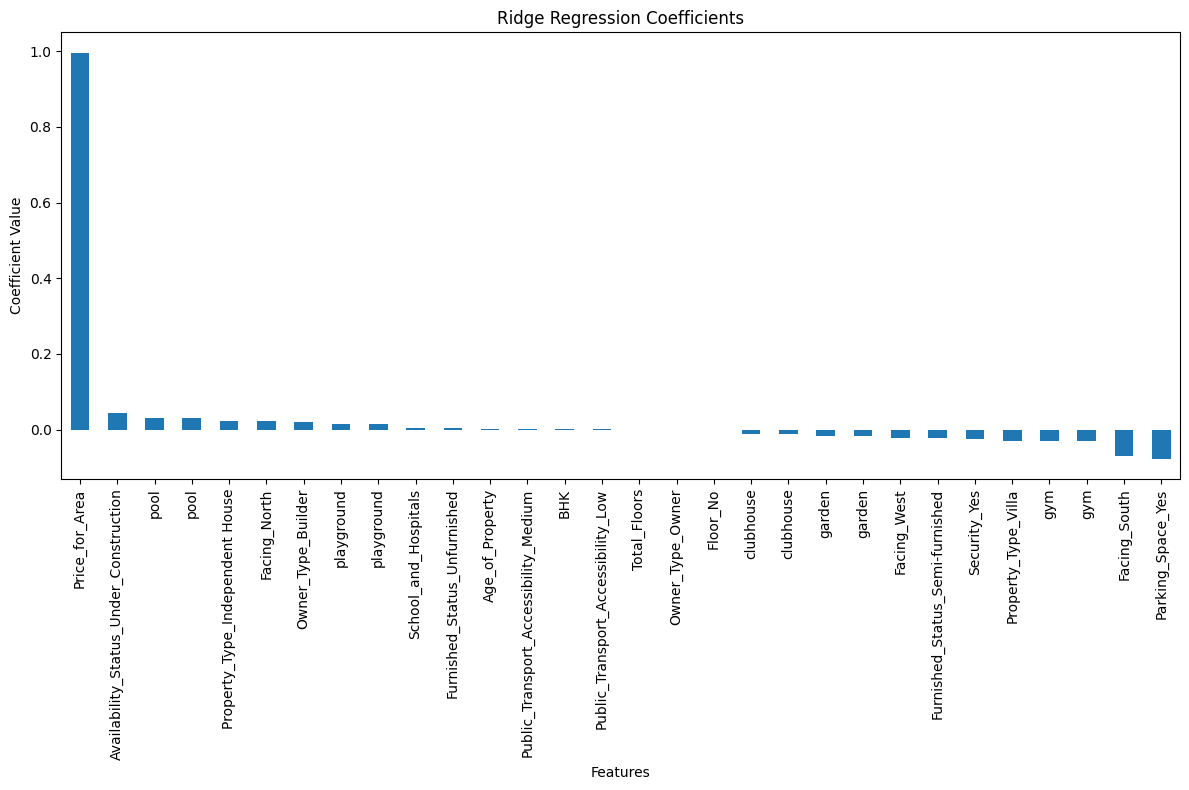

In [ ]:
plt.figure(figsize=(12, 8))
coefs = pd.Series(ridge_model.coef_, index=x_train.columns)
coefs.sort_values(ascending=False).plot(kind='bar')
plt.title('Ridge Regression Coefficients')
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

y_pred_val = ridge_model.predict(x_val)
r2 = r2_score(x_train, y_train)
print(f"R2 score on the validation set: {r2}")

R2 score on the validation set: 0.9961015640451987
